### Imports

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from statsmodels.tsa.api import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import Holt
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
import re

sns.set_theme(style="whitegrid", palette="viridis")

### Data Processing

In [20]:
calendar = pd.read_csv("./data/calendar_afcs2025.csv")
sell_prices = pd.read_csv("./data/sell_prices_afcs2025.csv")

sales_train_validation = pd.read_csv("./data/sales_train_validation_afcs2025.csv")
sales_test_validation = pd.read_csv("./data/sales_test_validation_afcs2025.csv")
sales_test_evaluation = pd.read_csv("./data/sales_test_evaluation_afcs_2025.csv")
submission = pd.read_csv("./data/sample_submission_afcs2025.csv")

Supplemental Nutrition Assistance Program (SNAP) program eligibility. This program provides food assistance to eligible households to cover a portion of a household's food budget (cite). 

In [21]:
sales_train_validation.columns
sales_test_validation.columns
sales_test_evaluation.columns

Index(['id', 'd_1942', 'd_1943', 'd_1944', 'd_1945', 'd_1946', 'd_1947',
       'd_1948', 'd_1949', 'd_1950', 'd_1951', 'd_1952', 'd_1953', 'd_1954',
       'd_1955', 'd_1956', 'd_1957', 'd_1958', 'd_1959', 'd_1960', 'd_1961',
       'd_1962', 'd_1963', 'd_1964', 'd_1965', 'd_1966', 'd_1967', 'd_1968',
       'd_1969'],
      dtype='object')

Based on the type of data we have and the way it is stored, we need to include some data processing in order to make the dataframes ready for modelling and visual representations.

For this project, we use a subset of the M5 dataset. This dataset contains hierarchical sales data made available by Walmart, involving the unit sales of various products sold in the USA. The data is classified into three product categories and seven product departments. We will be working especifically with one selected product, Food3, sold by the TX3 store in Texas.  
The three main components of the data consists of daily sales histories, calendar metatdata and prices for each item belonging to the product Food3. 
The sales dataset, "sales_train_validation", stores daily sales volumes for each product. Each row corresponds to a single item and each column represents a specific day (columns span from d_1 to d_1913). The wide format of this dataset can be compared to a sparse matrix, containing a lot of zero entries. This structure is not the most suitable for future modelling since data sparsity can lead to computational inefficiencies, statistical unreliability, and an increased risk of overfitting. In its original form, the sales dataset contains no explicit date information. These values are encoded through these columns in d_i format.  
The first step for the data processing is to overcome this challenge, reconstruct a proper time index where each day is aligned with its corresponding calendar date.

We can use the calendar file to fix this missing information. This file contains the actual date for each day of the dataset, together with additional contextual information, such as week number, weekday, month, year, holiday events, and Supplemental Nutrition Assistance Program (SNAP) program eligibility. The first step is realising that this dataset does not contain the d_i labels format found in the sales dataset, the way to bridge both datasets is then to assign a synthetic index to the calendar file, where 1 is assigned to the first day. This strategy serves as a join key.

In [22]:
calendar["d_index"] = calendar.index + 1    # row 0 = day 1

# all day columns
day_cols = [c for c in sales_train_validation.columns if c.startswith("d_")]

sales_long = sales_train_validation.melt(
    id_vars="id",
    value_vars=day_cols,
    var_name="d_col",
    value_name="sales"
)

# d_1 -> 1, d_2 -> 2, ...
sales_long["d_index"] = sales_long["d_col"].str.replace("d_", "").astype(int)


In [23]:
sales_long

,id,d_col,sales,d_index
0,FOODS_3_001_TX_3_validation,d_1,0,1
1,FOODS_3_002_TX_3_validation,d_1,0,1
2,FOODS_3_003_TX_3_validation,d_1,0,1
3,FOODS_3_004_TX_3_validation,d_1,0,1
4,FOODS_3_005_TX_3_validation,d_1,0,1
...,...,...,...,...
1574394,FOODS_3_823_TX_3_validation,d_1913,2,1913
1574395,FOODS_3_824_TX_3_validation,d_1913,0,1913
1574396,FOODS_3_825_TX_3_validation,d_1913,0,1913
1574397,FOODS_3_826_TX_3_validation,d_1913,2,1913


Before merging, the sales data are reshaped using a "melt" operation. With this transformation, the dataset now contains an item identifier for each row, as well as the day label (d_i), and corresponding sales values. This transformation creates a dataset where each row contains the item identifier, a day label (d_###), and the corresponding sales value. Each number in the d_i column names is converted into an integer stored in the column d_index. This process enables us to merge the sales data with the calendar data information.  
This merge is important, not just to enrich the sales observations available, but also to have a complete dataset that will allow us to obtain useful visual representations of the data and its behaviour. The sales data now are associated as well with meaningful temporal variables, improving interpretability and providing crucial features for later modelling. 

In [24]:
df = sales_long.merge(calendar, on="d_index", how="left")

# make date a proper datetime
df["date"] = pd.to_datetime(df["date"])
df.sample(10)


,id,d_col,sales,d_index,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_TX
201425,FOODS_3_615_TX_3_validation,d_245,0,245,2011-09-30,11135,Friday,7,9,2011,NaN,NaN,NaN,NaN,0
633384,FOODS_3_499_TX_3_validation,d_770,0,770,2013-03-08,11306,Friday,7,3,2013,NaN,NaN,NaN,NaN,0
1022974,FOODS_3_813_TX_3_validation,d_1243,0,1243,2014-06-24,11421,Tuesday,4,6,2014,NaN,NaN,NaN,NaN,0
205221,FOODS_3_296_TX_3_validation,d_250,0,250,2011-10-05,11136,Wednesday,5,10,2011,NaN,NaN,NaN,NaN,1
1295606,FOODS_3_206_TX_3_validation,d_1575,2,1575,2015-05-22,11516,Friday,7,5,2015,NaN,NaN,NaN,NaN,0
1407766,FOODS_3_438_TX_3_validation,d_1711,5,1711,2015-10-05,11536,Monday,3,10,2015,NaN,NaN,NaN,NaN,1
1172282,FOODS_3_332_TX_3_validation,d_1425,6,1425,2014-12-23,11447,Tuesday,4,12,2014,NaN,NaN,NaN,NaN,0
828633,FOODS_3_697_TX_3_validation,d_1007,1,1007,2013-10-31,11340,Thursday,6,10,2013,Halloween,Cultural,NaN,NaN,0
1293417,FOODS_3_486_TX_3_validation,d_1572,1,1572,2015-05-19,11516,Tuesday,4,5,2015,NaN,NaN,NaN,NaN,0
458265,FOODS_3_679_TX_3_validation,d_557,5,557,2012-08-07,11228,Tuesday,4,8,2012,NaN,NaN,NaN,NaN,1


In [25]:
df["base_id"] = (
    df["id"]
    .str.replace("_validation$", "", regex=True)
    .str.replace("_evaluation$", "", regex=True)
)

parts = df["base_id"].str.split("_", expand=True)
# parts columns: 0,1,2,3,4  -> FOODS | 3 | 001 | TX | 3

# FOODS_3_001
df["item_id"]  = parts[0] + "_" + parts[1] + "_" + parts[2]
df["store_id"] = parts[3] + "_" + parts[4]

df = df.drop(columns=["base_id"])

In [26]:
df = df.merge(
    sell_prices,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)

In [27]:
# Ensure correct ordering
df = df.sort_values(["item_id", "wm_yr_wk"])

# Compute week-to-week price difference
df["price_change"] = df.groupby("item_id")["sell_price"].diff()

The missing component of this database is the sell_prices dataset. This dataset contains the price of each item in each store for each retail week. In our previous work with the dataset processing, we observed that the store and item information are found withing the id string (e.g., "FOODS_3_001_TX_3_validation"). In order to incorporate the sell prices to the sales data, we extract the item ids and store ids by parsing this identifier column. These files now allow us carry on with the final merging.  
For this project it is essential to align the prices with the sales, price can be defined as one of the most influential factors for demand variations throughout different periods of time.  
Once merged, the final dataset includes the actual price on each specific week and we can infer the changes in price over time. We compute the price change by taking each item’s weekly price history, sorting it by week, and subtracting each week’s price from the previous one. This shows how much an item’s price increases or decreases from week to week. The price changes can help us identify promotions, price drops, and potential data inconsistencies.

#### Missing values

In [28]:
df.isna().sum().sort_values(ascending=False)

event_type_2    1571107
event_name_2    1571107
event_name_1    1447657
event_type_1    1447657
price_change     328605
sell_price       327782
store_id              0
item_id               0
snap_TX               0
id                    0
d_col                 0
month                 0
wday                  0
weekday               0
wm_yr_wk              0
date                  0
d_index               0
sales                 0
year                  0
dtype: int64

In [29]:
df = df.sort_values(["id", "date"])
df["snap_TX"] = df["snap_TX"].astype(int)


# fill in missing sales
df["sales"] = df["sales"].fillna(0)

# Missing prices can be interpreted as item not sold that week --> fill forward/backward
df["sell_price"] = df.groupby("id")["sell_price"].ffill().bfill()

# Events with missing values can be filled with "None"
df["event_name_1"] = df["event_name_1"].fillna("None")
df["event_type_1"] = df["event_type_1"].fillna("None")
df["event_name_2"] = df["event_name_2"].fillna("None")
df["event_type_2"] = df["event_type_2"].fillna("None")

# df.isna().sum().sort_values(ascending=False)

One of the most important steps of data preprocessing and before we can start with nay modelling, is checking for missing values in our dataset. 
This ananlysis reveals that the event variables contain the most amount of missing values, which an expected finding since most days are not holidays or special events. In order to account for these, the solution chosen was to directly substitude the missing values for the string "None", specifying that day does not account as a special event or holidays. A smaller number of missing sell price values is observed as well. The selling price is recorded only for the weeks in which a product was actually sold in a particular store. Prices are reported at the weekly level (wm_yr_wk), not daily. Therefore missing values can be translated to certain product not being sold in this store during a certain week. To prepare the data for forecasting we want every day to have the correct weekly price associated with that period. This can be achieved by using the forward and backward-filling method within each item group. With forward filling we fill missing prices using the last known price for the same item, whereas if we have the special case with beginning of series gaps, we will use backward filling with the next known price. 

In [30]:
# Ensure correct ordering and compute price change
df = df.sort_values(["item_id", "wm_yr_wk"])
df["price_change"] = df.groupby("item_id")["sell_price"].diff()

# Price_change NaNs (first week) can be filled with 0
df["price_change"] = df["price_change"].fillna(0)

# Filter out only the weeks where price changed
price_changes = df[df["price_change"].notna() & (df["price_change"] != 0)]

# Select important columns
df_price_change = price_changes[
    ["item_id", "wm_yr_wk", "sell_price", "price_change", "event_name_1", "event_type_1", "event_name_2", "event_type_2", "snap_TX"]
    ].reset_index(drop=True)

df_price_change


,item_id,wm_yr_wk,sell_price,price_change,event_name_1,event_type_1,event_name_2,event_type_2,snap_TX
0,FOODS_3_001,11115,2.50,0.22,None,None,None,None,1
1,FOODS_3_001,11117,1.25,-1.25,None,None,None,None,0
2,FOODS_3_001,11118,2.50,1.25,None,None,None,None,0
3,FOODS_3_001,11123,0.99,-1.51,None,None,None,None,0
4,FOODS_3_001,11124,2.50,1.51,None,None,None,None,1
...,...,...,...,...,...,...,...,...,...
3416,FOODS_3_825,11132,3.98,-0.40,None,None,None,None,1
3417,FOODS_3_825,11135,4.38,0.40,None,None,None,None,0
3418,FOODS_3_825,11322,3.98,-0.40,None,None,None,None,0
3419,FOODS_3_827,11602,0.50,-0.50,None,None,None,None,1


After cleaning the data, more exploration is done on the price changes thoughout each week.  
To begin, the dataset is first sorted by `item_id` and by the retail week variable `wm_yr_wk`, that way each item's price history is ordered in chronological order. Once the week-to-week orde is stablished, we calculate the price chances. For each item, the price change shows the difference betwen the current week's sale price and the previous week's price. The first observation of each week will have no previous week to be compared with, therefore it will result in a `NaN` value. In order to avoid including any column with missing data, these cases were filled with zeros. 

In order to get more understanding in the behaviour of price changes over time, we filter the dataset so that only meaningful changes remain. Meaningful changes are interpreted as those rows in which a price change can be observed, that is the value is different than zero. The resulting dataset contains each week in which a price changed occurred for a particular item. 

In [31]:
# Event-related price changes
event_changes = df_price_change[
    df_price_change["event_name_1"].notna() | df_price_change["event_name_2"].notna()
].copy()

# Combine event_name_1 and event_name_2 into a single column
event_changes["event"] = event_changes["event_name_1"].fillna(
    event_changes["event_name_2"]
)

# SNAP-related price changes
event_changes["SNAP_flag"] = event_changes["snap_TX"].astype(int)

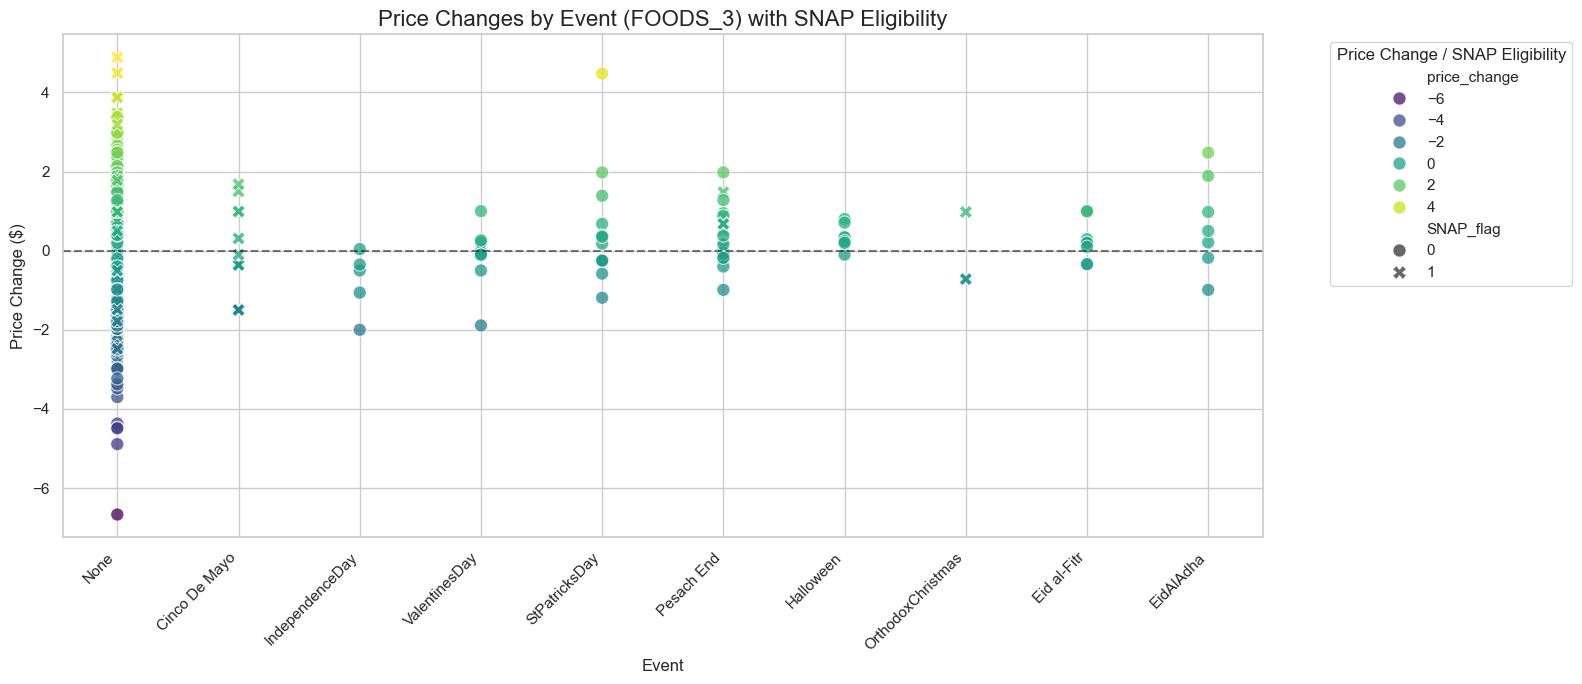

In [32]:
plt.figure(figsize=(16, 7))

sns.scatterplot(
    data=event_changes,
    x="event",
    y="price_change",
    hue="price_change",
    style="SNAP_flag",
    palette="viridis",
    s=90,
    alpha=0.75,
)

plt.title("Price Changes by Event (FOODS_3) with SNAP Eligibility", fontsize=16)
plt.xlabel("Event")
plt.ylabel("Price Change ($)")
plt.xticks(rotation=45, ha="right")
plt.axhline(0, color="black", linestyle="--", alpha=0.5)
plt.legend(title="Price Change / SNAP Eligibility", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


During special occasions such as national days or holidays, consumers behaviours change, usually responding with more products bought (cite). Retailers respond to these changes by raising the prices of certain products, lowering prices by introducing discounts or special promotions, or just by leaving them stable to remain competitive (cite). An interesting addition to our data exploration is the study of price changes during these especial days, as previously explained, events translate in a shift in demand. Understanding how these prices behave during these moments reveals important economic, behavioral, and forecasting insights for future modelling. 

For a more visual understanding we creat the plot above to analyse the changes. We also include whether a certain week was SNAP eligible, in order to study as well its correlation with holidays.  
Since the big majority of our data falls outside a special day or holiday, the majority of adjustments is found within the label "None". Nevertheless, we can still affirm that retailers still modify their prices during regular weeks rather than aligning them with specific holidays and events. This suggests that the pricing strategy for this category may rely more on suppliers cost, inventory cycles, or even internal pricing demands and policies.  
We can still observe several events still showcase price adjustments in a smaller scale. When price changes do occur during these events, they tend to cluster nearer to zero, meaning that even though some tuning was included during the events, they remain modest and do not oblige with higher discount strategies. However, certain holidays, especially St. Patrick’s Day and Cinco de Mayo, exhibit several positive or negative changes with a higher drift from their original prices. 

We can observe a few points that experienced a large modification, found in those days without events. This likely represents either outliers present in the data or more extreme conditions such as clearance pricing (likely for end-of-life products), or reactions to supply spikes.

SNAP-eligible weeks (marked with x) are scattered across the event and non-event weeks, however there is no clustering at extreme pricing values. This suggests no strong pricing strategies dedicated to SNAP consumption for the FOODS_3 products.

### Plots

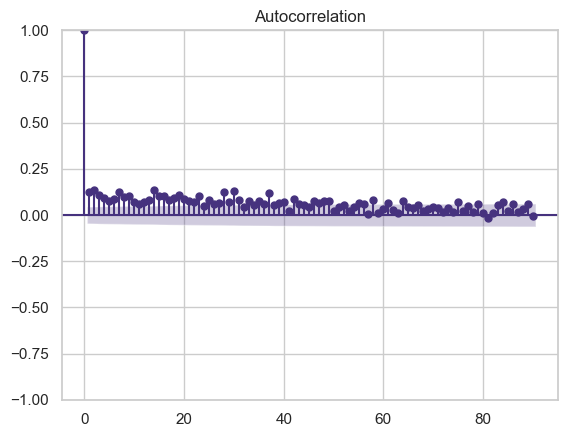

In [33]:
from statsmodels.graphics.tsaplots import plot_acf

item = df["id"].iloc[0]
plot_acf(df[df["id"] == item]["sales"], lags=90)
plt.show()

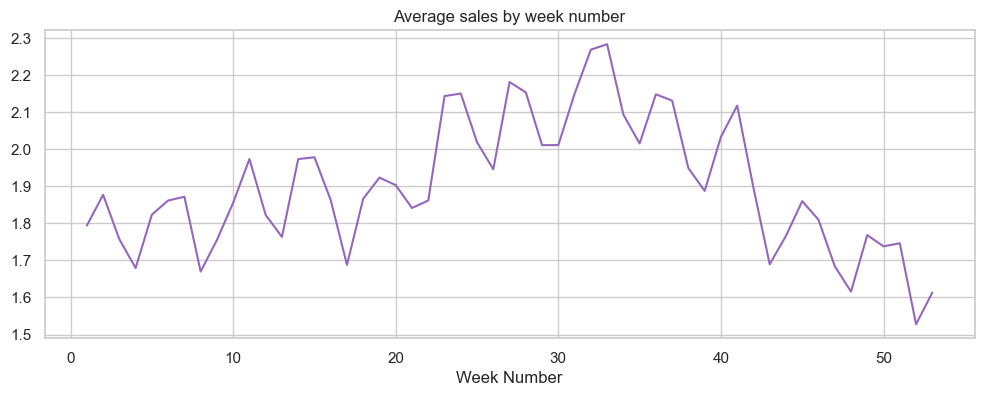

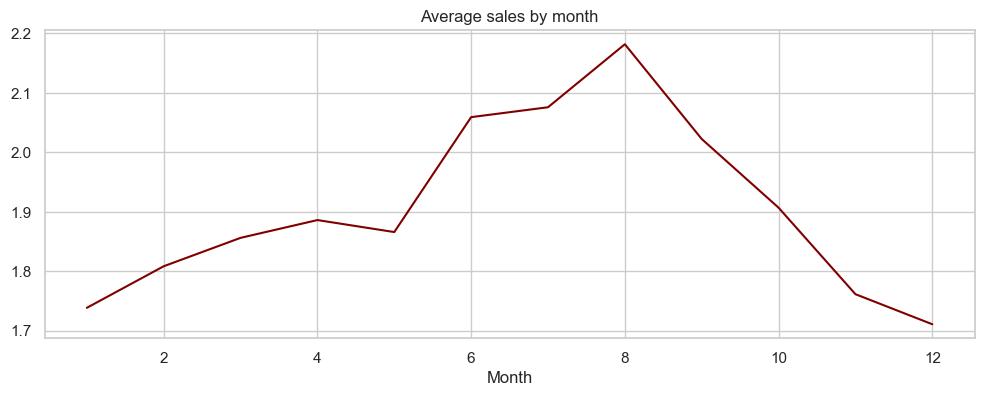

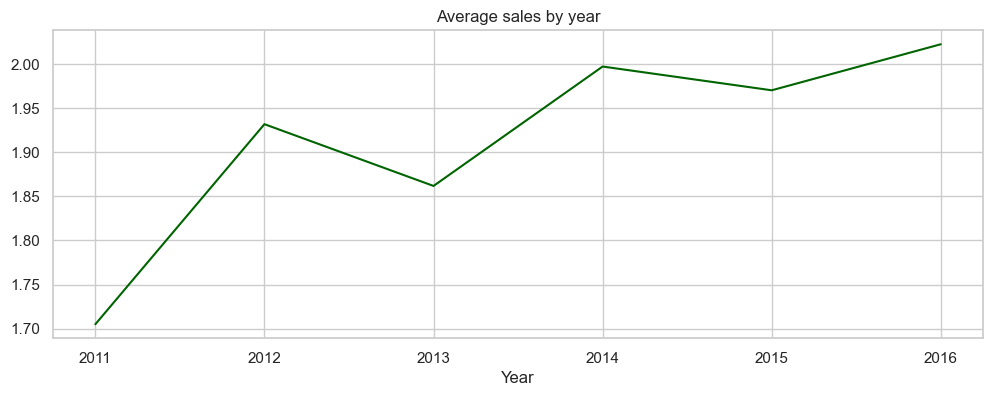

In [34]:
weekly_sales = df.groupby(df["date"].dt.isocalendar().week)["sales"].mean()
monthly_sales = df.groupby(df["date"].dt.month)["sales"].mean()
yearly_sales = df.groupby(df["date"].dt.year)["sales"].mean()

weekly_sales.plot(figsize=(12,4), title="Average sales by week number", color="#9467bd")
plt.xlabel("Week Number")
plt.show()

monthly_sales.plot(figsize=(12,4), title="Average sales by month", color="#800000")
plt.xlabel("Month")
plt.show()

yearly_sales.plot(figsize=(12,4), title="Average sales by year", color="darkgreen")
plt.xlabel("Year")
plt.show()

From the yearly average sales plot we can observe a clear upward trend. From 2011 to 2016, sales gradually increase overall, despite showing small dips in 2013 and 2015. This suggests a slow upward graph in the demand for the items belonging to the product category encoded as FOODS_3 at this particular store in Texas. This trend can possibly reflect the population growth in the are, or even an increased market share.  

For a more clear understanding of the sales behaviour within each year, we plotted the average monthly and weekly sales. From these graphs we can observe very strong seasonality, sales consistently rise from early in the year, experimenting the highest peak around mid and end of summer (shown in months 6-8 and weeks 25-35). After this, the sales decline sharply as colder seasons begin. Since this pattern repeats every year, it translates to predictable seasonality occurences, such as holidays, weather-driven conditions, or school cycles. Even though these plots show the average sales by month and week, we can affirm this is consistent yearly behaviour based on such clean and repeating curves presented in the graphs. The only way this shape can form is if each year shares the same pattern. The consistency of the peaks and troughs present in the data, suggests seasonality is one of the main dynamics of this dataset.

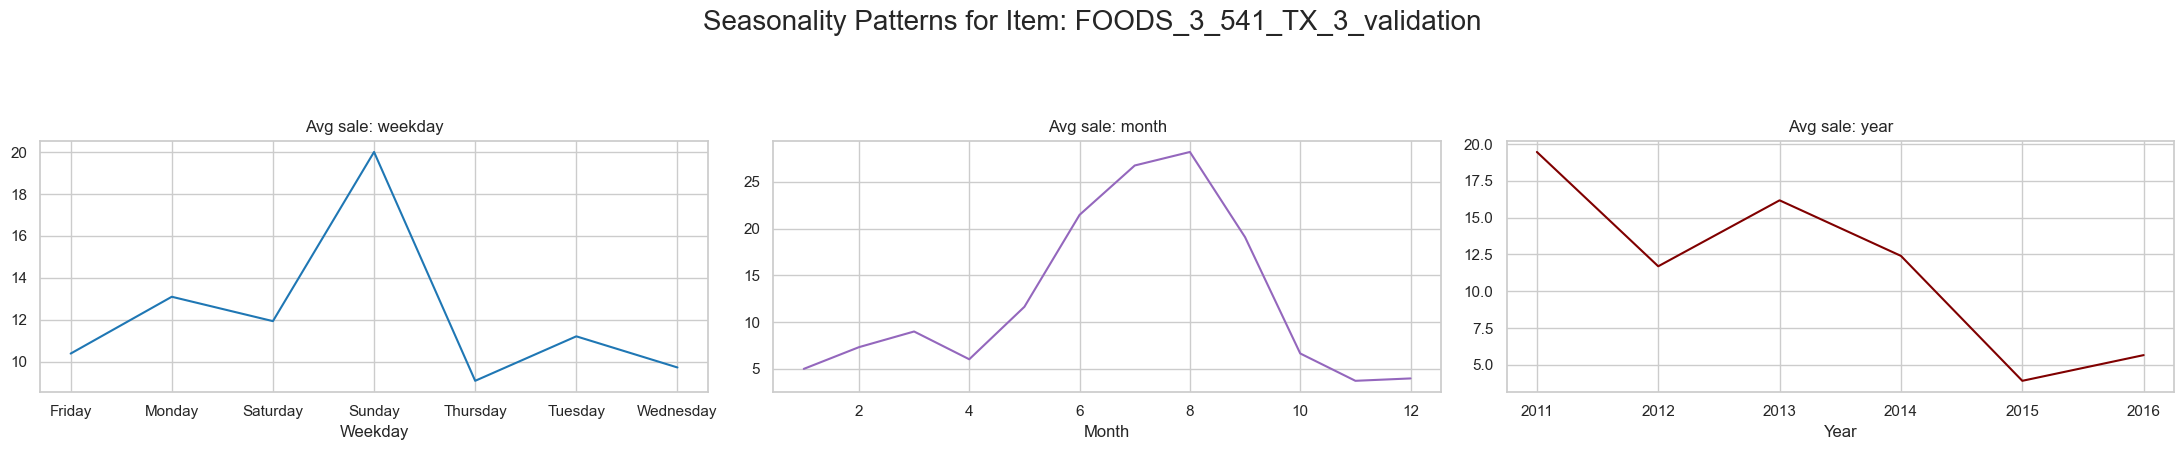

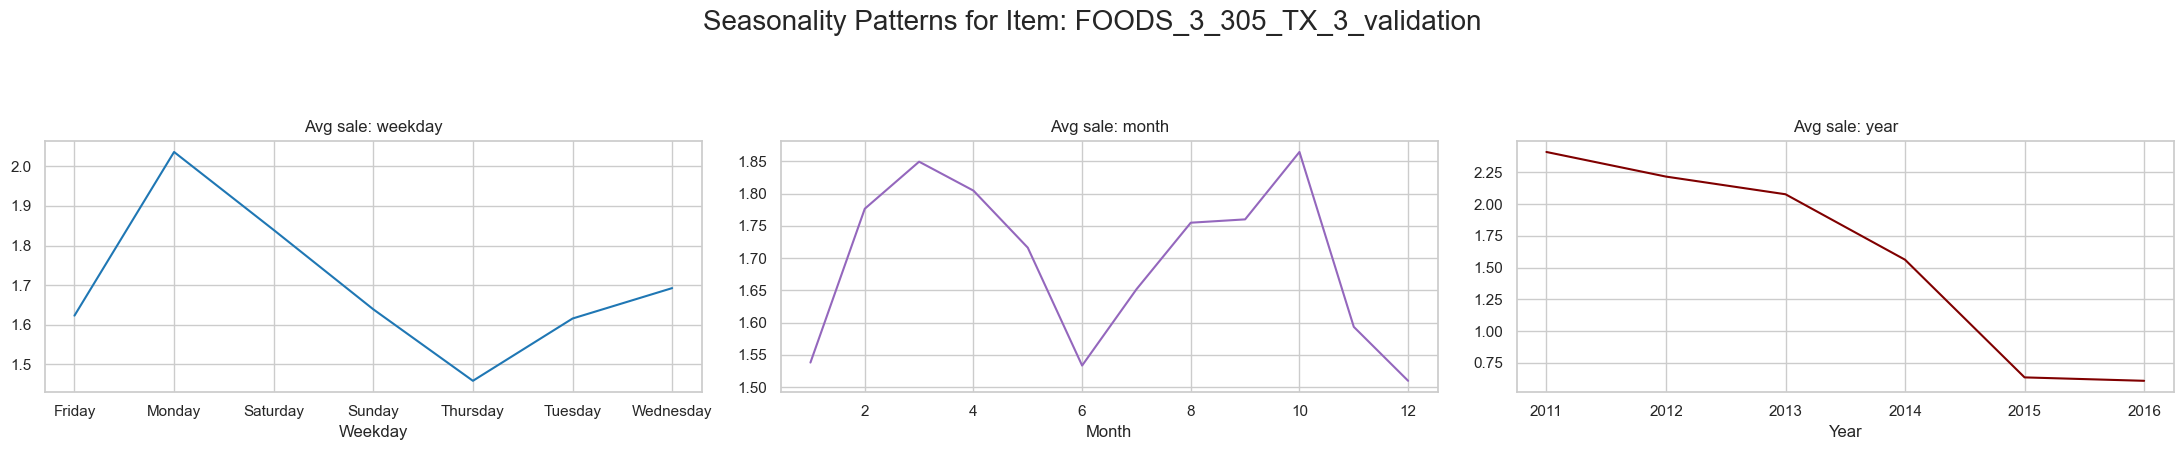

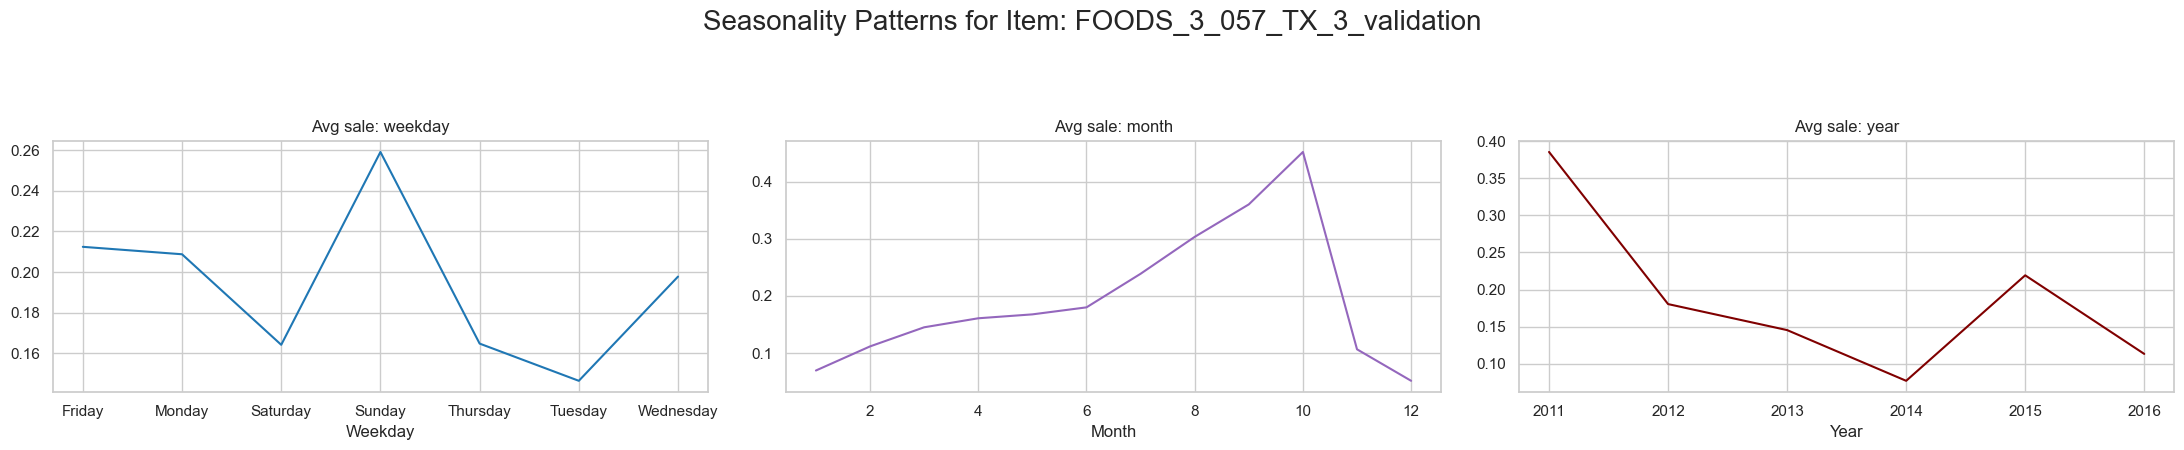

In [35]:
def plot_seasonality(item_id):
    item_df = df[df["id"] == item_id]

    # Colors (blue, purple, maroon)
    color_weekday = "#1f77b4"   # blue
    color_month   = "#9467bd"   # purple
    color_year    = "#800000"   # maroon

    # Create subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 4))

    # Weekday seasonality
    item_df.groupby("weekday")["sales"].mean().plot(
        kind="line", ax=ax1, color=color_weekday
    )
    ax1.set_title("Avg sale: weekday")
    ax1.set_xlabel("Weekday")

    # Month seasonality
    item_df.groupby("month")["sales"].mean().plot(
        kind="line", ax=ax2, color=color_month
    )
    ax2.set_title("Avg sale: month")
    ax2.set_xlabel("Month")

    # Year seasonality
    item_df.groupby("year")["sales"].mean().plot(
        kind="line", ax=ax3, color=color_year
    )
    ax3.set_title("Avg sale: year")
    ax3.set_xlabel("Year")

    # Suptitle moved up (does not collide with subtitles)
    fig.suptitle(
        f"Seasonality Patterns for Item: {item_id}",
        fontsize=20,
        y=1.12
    )

    plt.tight_layout()
    plt.show()

random_ids = np.random.choice(df["" \
"id"].unique(), size=3, replace=False)
for id in random_ids:
    plot_seasonality(id)

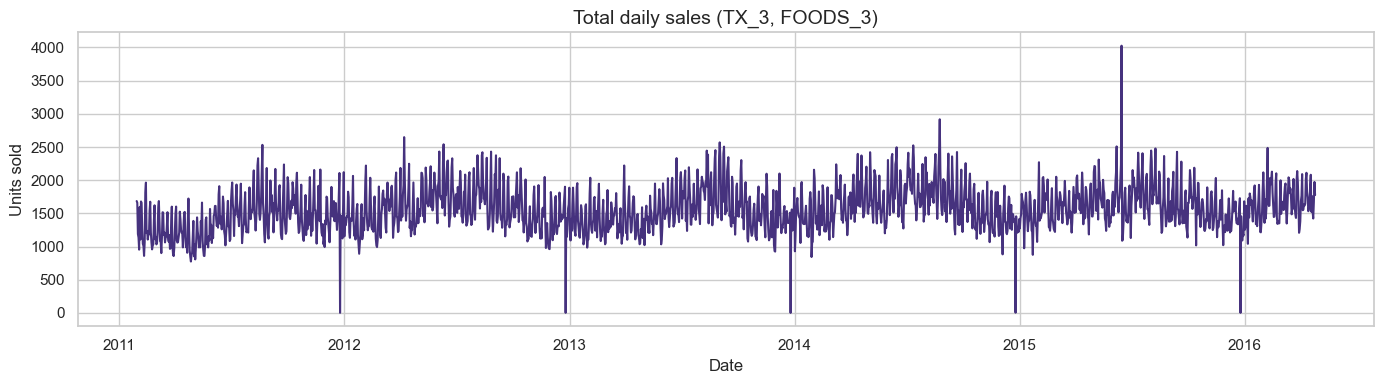

In [36]:
# Aggregate once
daily_total = df.groupby("date", as_index=False)["sales"].sum()

plt.figure(figsize=(14, 4))
ax = sns.lineplot(data=daily_total, x="date", y="sales")
ax.set_title("Total daily sales (TX_3, FOODS_3)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Units sold")

# Optional: rotate x-labels a bit
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In order to get a better grasp at the yearly behaviour of the sales, we plot the total number of units sold per day across all FOODS_3 items over each years. The graphs shows stronger yearly seasonality than what was observed in the average sales per year in the plot above. Each year, sales rice and fall in a similar cyclical shape. We can observe higher peaks around the middle of each year, and harsher declines at the end of each year. We can see certain troughs and one particular peak in 2015 that are more dramatic than what is seen throughout the rest of the years. These troughs, with values close to zero, likely correspond with major holidays when stores are closed, such as Christmas and New Year. The higher peaks may be related to certain promotion days or holidays. Overall, the graph reflect both long-term seasonal cycles and high-frequency noise. 

Since there is such a wide range of different items corresponding to the same product, we decided to check as well the individual behaviour of random items:

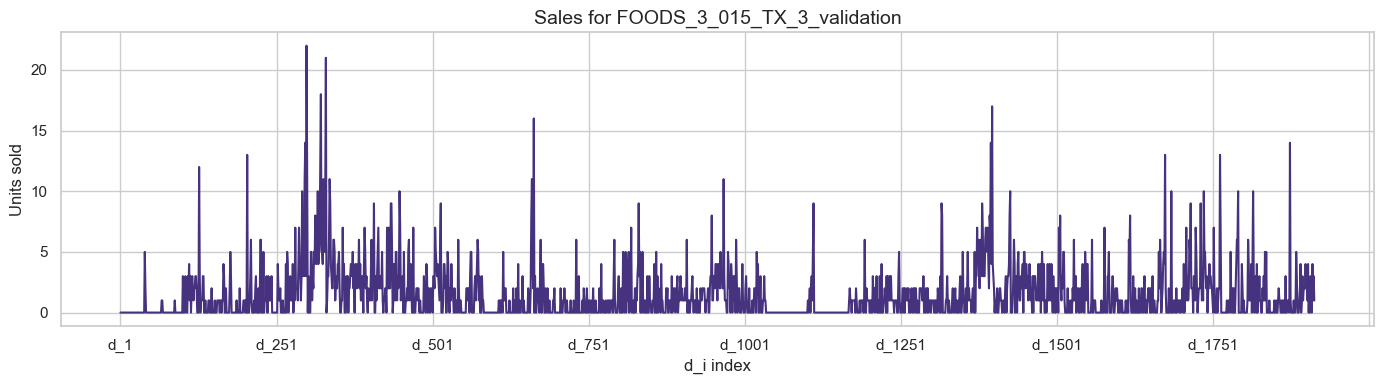

In [37]:
def plot_item_sales(item_id, use_date=True):
    item_df = df[df["id"] == item_id].copy()

    if use_date:
        x_col = "date"
        x_label = "Calendar date"
    else:
        x_col = "d_col"
        x_label = "d_i index"

    plt.figure(figsize=(14, 4))
    ax = sns.lineplot(data=item_df, x=x_col, y="sales")
    ax.set_title(f"Sales for {item_id}", fontsize=14)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Units sold")

    if use_date:
        plt.xticks(rotation=0)
    else:
        # fewer ticks so labels don't overlap
        ax.xaxis.set_major_locator(plt.MaxNLocator(10))

    plt.tight_layout()
    plt.show()

# Examples
# plot_item_sales(df["id"].iloc[27000], use_date=True)
plot_item_sales(df["id"].iloc[27000], use_date=False)



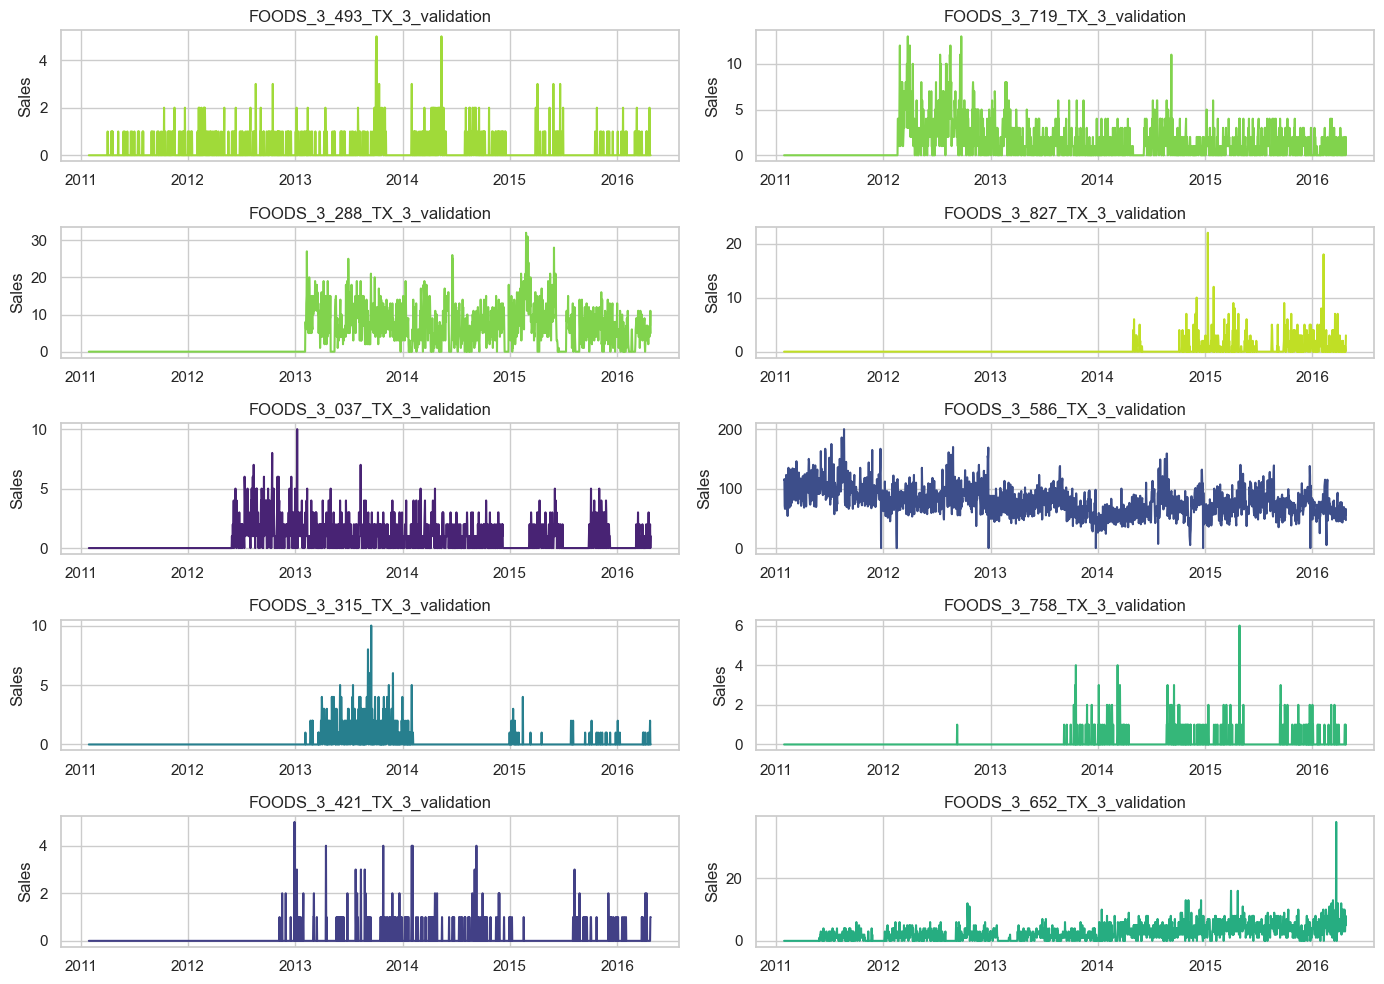

In [38]:
# get viridis palette with 20 colors
viridis_colors = sns.color_palette("viridis", 20)

# pick 10 random item IDs
sample_ids = np.random.choice(df["id"].unique(), size=10, replace=False)

fig, axs = plt.subplots(5, 2, figsize=(14, 10))
axs = axs.flatten()

for ax, item_id in zip(axs, sample_ids):

    tmp = df[df["id"] == item_id].set_index("date")["sales"]

    # pick a random viridis color
    color = viridis_colors[np.random.choice(len(viridis_colors))]

    sns.lineplot(ax=ax, x=tmp.index, y=tmp.values, color=color)

    ax.set_title(item_id, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Sales")

plt.tight_layout()
plt.show()



Across the different items, the sales patterns are completely heterogeneous and varied. Some items sell consistently (e.g., FOODS_3_163 or FOODS_3_063), but still with large day-to-day noise. On the other hand, we can see some items with long stretches of zero sales followed by a sudden sales introduction or growth (e.g., FOODS_3_170 or FOODS_3_125). We can observe as well an item with a more strange performance, FOODS_3_098, with very low sales values thought all the time period but with an extreme spike in 2012. This makes forecasting for this kind of behaviour more challenging. A few items seem seasonal or periodic, but the signal is extremely weak compared to the noise.

We saw from the aggregated category-level that sales for FOOD_3 have clear and smooth seasonality, repeating each year. But when we zoomed into a single item, that structure nearly disappeares due to items showcasing spares sales and more volatile behaviour. Plotting the individual sales progression reinforces that seasonality exists at the group level, but individual items vary widely. 

We need to find a model that will learn a stable seasonal pattern from aggregated data, while still predicting highly volatile behaviour at the individual level. 

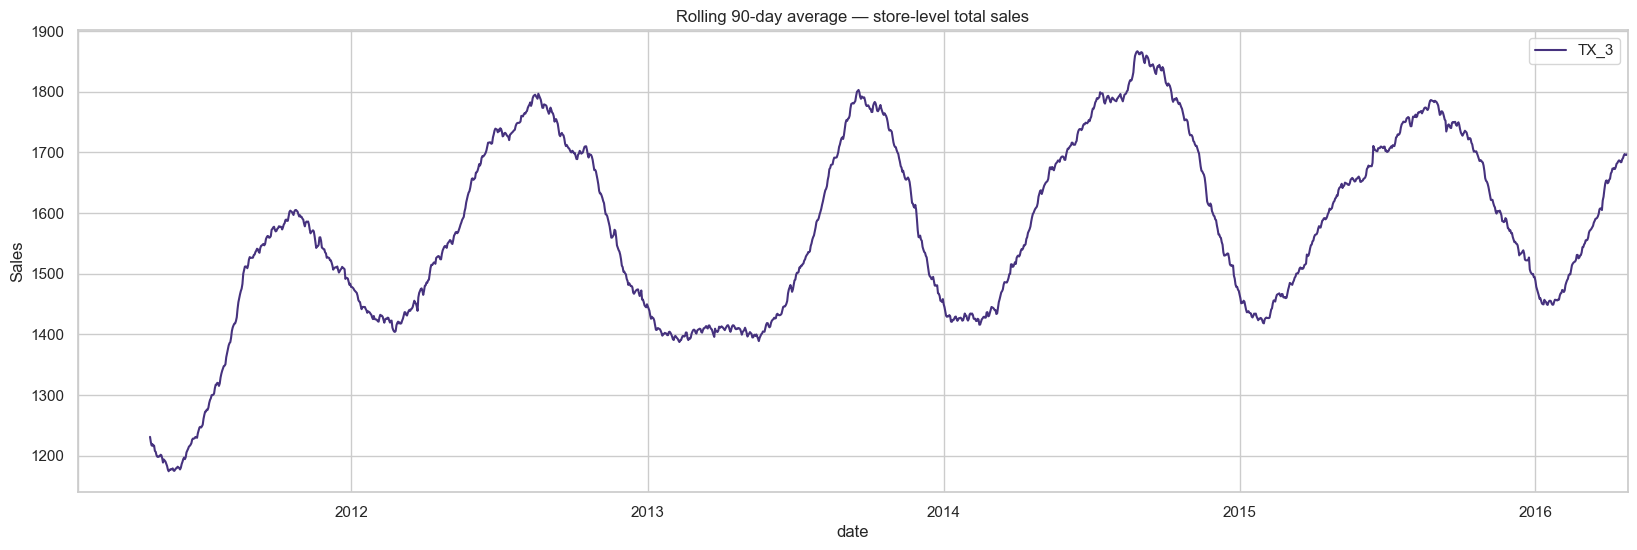

In [39]:
store_list = df["store_id"].unique()

fig, ax = plt.subplots(figsize=(20,6))

for store in store_list:
    tmp = df[df["store_id"] == store]
    rolling = tmp.groupby("date")["sales"].sum().rolling(90).mean()
    rolling.plot(label=store)

ax.set_title("Rolling 90-day average — store-level total sales")
ax.set_ylabel("Sales")
plt.legend()
plt.show()

In order to double check the yearly behaviour we investidated the rolling 90-day average of total store-level sales. We can clearly see a smooth, repeating yearly cycle where the behaviour we had previoiusly observed is reinforced. We can see the upward trend observed throughout all the years, together with the monthly seasonality. Sales rise toward the middle of the year and decline afterward. This is strong evidence of macro-level seasonal demand patterns that repeat consistently from 2011 to 2016.

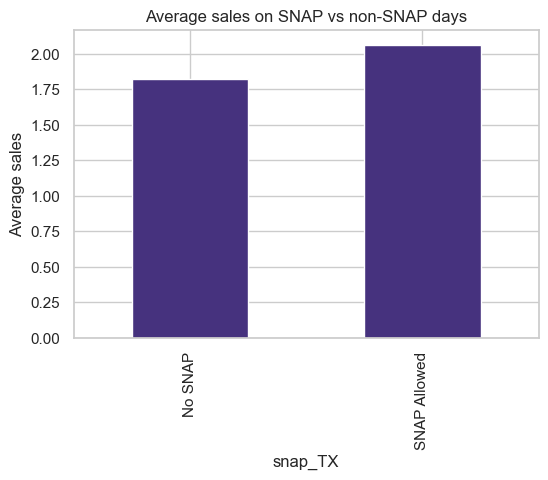

In [40]:
snap_df = df.groupby("snap_TX")["sales"].mean()

snap_df.plot(kind="bar", figsize=(6,4))
plt.title("Average sales on SNAP vs non-SNAP days")
plt.xticks([0,1], ["No SNAP", "SNAP Allowed"])
plt.ylabel("Average sales")
plt.show()

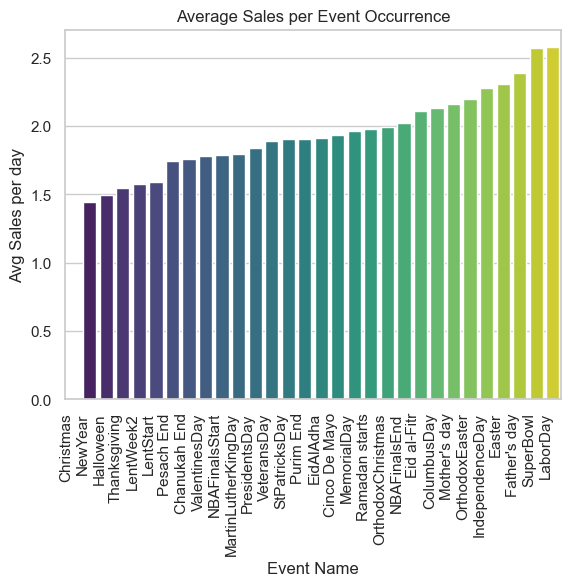

In [41]:
event_grouped = (
    df[df["event_name_1"] != "None"]
    .groupby("event_name_1")
    .agg(
        total_sales=("sales", "sum"),
        count=("event_name_1", "count"),
    )
)

event_grouped["avg_sales"] = event_grouped["total_sales"] / event_grouped["count"]
event_grouped = event_grouped.sort_values("avg_sales")

sns.barplot(data=event_grouped, x=event_grouped.index, y="avg_sales", hue=event_grouped.index, palette="viridis")
plt.xticks(rotation=90, ha="right")
plt.title("Average Sales per Event Occurrence")
plt.ylabel("Avg Sales per day")
plt.xlabel("Event Name")
plt.show()


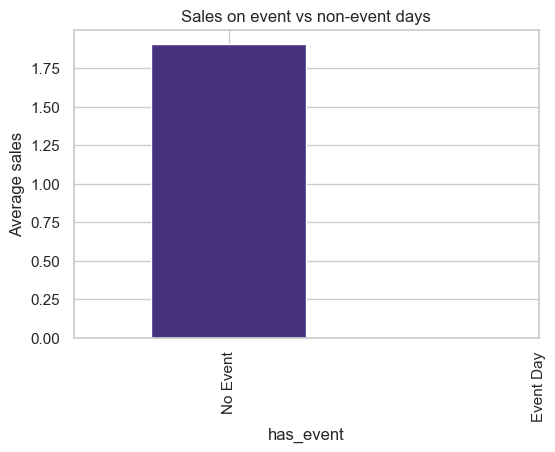

In [42]:
df["has_event"] = df["event_name_1"].notna().astype(int)

df.groupby("has_event")["sales"].mean().plot(kind="bar", figsize=(6,4))
plt.xticks([0,1], ["No Event", "Event Day"])
plt.title("Sales on event vs non-event days")
plt.ylabel("Average sales")
plt.show()

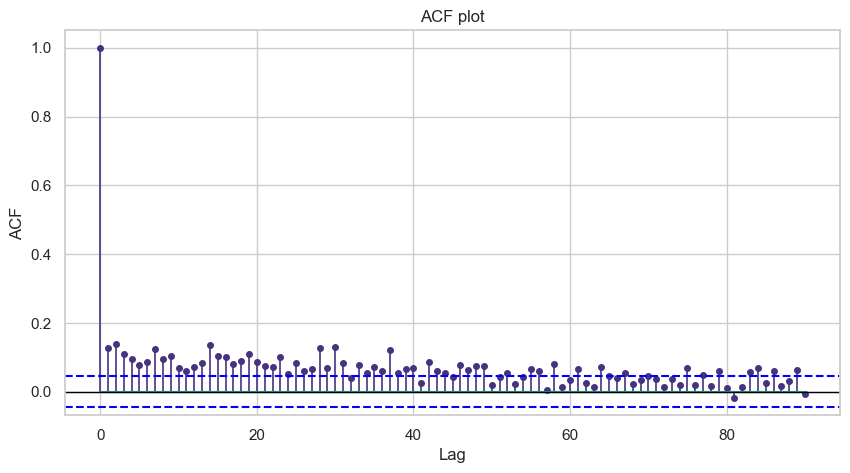

In [43]:
from statsmodels.tsa.stattools import acf

def plot_acf(series, lags=40):
    series = np.asarray(series)
    n = len(series)

    acf_vals = acf(series, nlags=lags)

    # R-style CI
    ci = 1.96 / np.sqrt(n)

    fig, ax = plt.subplots(figsize=(10, 5))

    markerline, stemlines, baseline = ax.stem(range(len(acf_vals)), acf_vals)
    plt.setp(stemlines, linewidth=1.2)
    plt.setp(markerline, markersize=4)

    # CI lines (like R)
    ax.axhline(ci, color="blue", linestyle="--")
    ax.axhline(-ci, color="blue", linestyle="--")

    ax.axhline(0, color="black", linewidth=1)

    ax.set_title("ACF plot")
    ax.set_xlabel("Lag")
    ax.set_ylabel("ACF")

    plt.show()

item = df["id"].iloc[0]
series = df[df["id"] == item]["sales"]
plot_acf(series, lags=90)

### Preparing the data

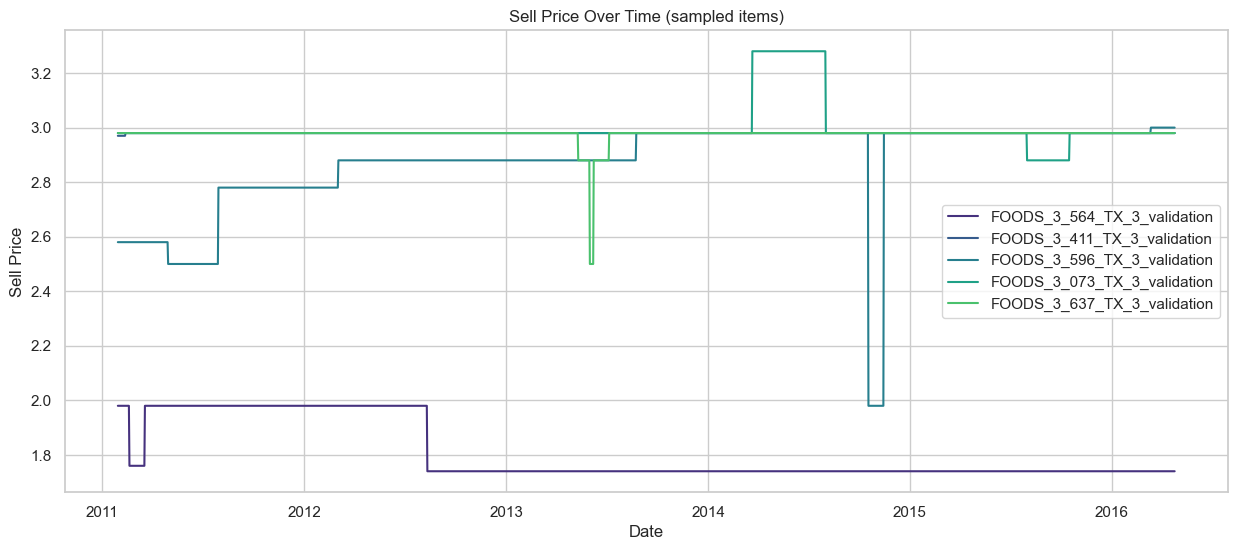

In [44]:
sample_ids = np.random.choice(df["id"].unique(), 5, replace=False)

plt.figure(figsize=(15,6))

for item in sample_ids:
    tmp = df[df["id"] == item].sort_values("date")
    plt.plot(tmp["date"], tmp["sell_price"], label=item)

plt.title("Sell Price Over Time (sampled items)")
plt.ylabel("Sell Price")
plt.xlabel("Date")
plt.legend()
plt.show()


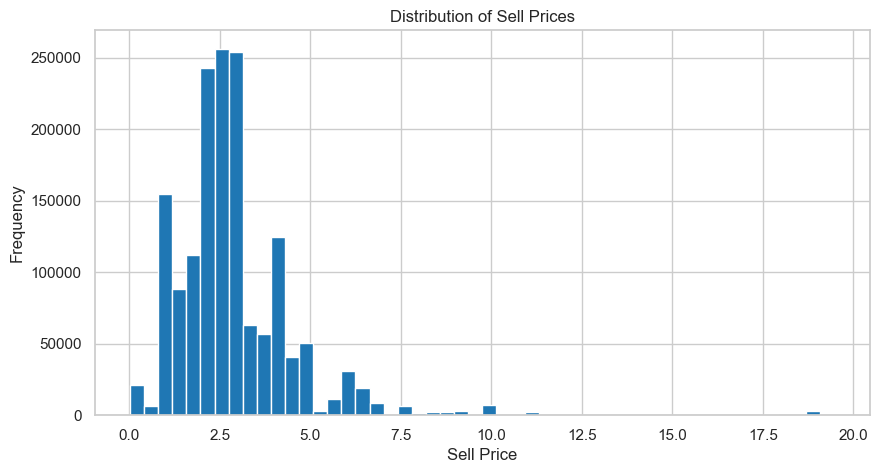

In [45]:
plt.figure(figsize=(10,5))
plt.hist(df["sell_price"].dropna(), bins=50, color="#1f77b4")
plt.title("Distribution of Sell Prices")
plt.xlabel("Sell Price")
plt.ylabel("Frequency")
plt.show()

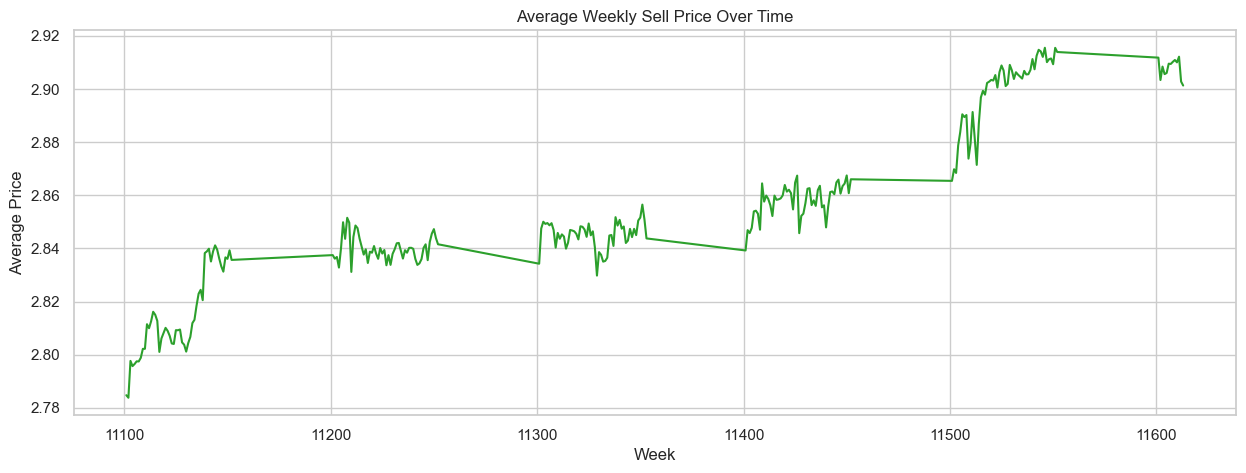

In [46]:
weekly_avg = df.groupby("wm_yr_wk")["sell_price"].mean()

plt.figure(figsize=(15,5))
weekly_avg.plot(color="#2ca02c")
plt.title("Average Weekly Sell Price Over Time")
plt.ylabel("Average Price")
plt.xlabel("Week")
plt.show()

Store-level patterns can hide a lot of product-specific variation. That is why we included as well exploration on the sell prices for individual and group aggreated items. For individual items, the prices tend to have a piecewise constant behaviour, changing only ocasionally but resulting a slightly higher or the same price. Even though this is a small range of items presented to explore the relationship between price and demand, we can say that this will depend on discrete change points rather than on smooth trends in the data. Different items follow completely different pricing changes, some may change more frequently, while others may remain fixed alost throught the entire time period.

Because these price changes happen at the item level, we include a plot to represent the average weekly price across all FOODS_3 items. This shows whether the overall price environment in the department evolves over time. Here, we observe a gently increasing trend with small step-wise jumps. This indicates that while individual price series are noisy and heterogeneous, the aggregated pricing behaviour is more stable and easier to interpret.

In [47]:
# Lag features
df["lag_1"] = df.groupby("id")["sales"].shift(1)
df["lag_7"] = df.groupby("id")["sales"].shift(7)
df["lag_28"] = df.groupby("id")["sales"].shift(28)

### Initial Modelling

In [48]:
def make_wide_sales_matrix(df_long: pd.DataFrame) -> pd.DataFrame:
    df = df_long.copy()

    # Ensure day ordering key exists
    if "d_index" not in df.columns:
        # if you only have d_col like "d_123", extract the number
        df["d_index"] = df["d_col"].str.replace("d_", "", regex=False).astype(int)

    # Build wide matrix: rows=item ids, cols=days (use d_index for stable sort)
    wide = (
        df.pivot_table(index="id", columns="d_index", values="sales", aggfunc="sum")
        .sort_index(axis=1)
    )

    # Rename columns back to d_#
    wide.columns = [f"d_{int(c)}" for c in wide.columns]
    wide = wide.sort_index(axis=1)

    return wide

sales_wide = make_wide_sales_matrix(df)
print(sales_wide.shape)


def sort_d_cols(df_wide: pd.DataFrame) -> pd.DataFrame:
    d_cols = [c for c in df_wide.columns if isinstance(c, str) and c.startswith("d_")]
    other_cols = [c for c in df_wide.columns if c not in d_cols]

    d_cols_sorted = sorted(d_cols, key=lambda x: int(x.split("_")[1]))
    return df_wide[other_cols + d_cols_sorted]

sales_wide = sort_d_cols(sales_wide)

# sanity check
print(sales_wide.columns[:10])
print(sales_wide.columns[-10:])


(823, 1913)
Index(['d_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10'], dtype='object')
Index(['d_1904', 'd_1905', 'd_1906', 'd_1907', 'd_1908', 'd_1909', 'd_1910',
       'd_1911', 'd_1912', 'd_1913'],
      dtype='object')


In [49]:
def rmse_matrix(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

In [50]:
d_cols = [c for c in sales_wide.columns if c.startswith("d_")]
d_cols = sorted(d_cols, key=lambda x: int(x.split("_")[1]))

train_cols = d_cols[:-28]
val_cols   = d_cols[-28:]

train = sales_wide[train_cols]
val   = sales_wide[val_cols]

In [68]:
def plot_forecasting_graph(
    item_id,
    train_df,
    val_df,
    pred,
    tail=100
):
    import matplotlib.pyplot as plt

    train_series = train_df.loc[item_id]
    val_series   = val_df.loc[item_id]
    pred_series  = pred[train_df.index.get_loc(item_id)]

    # Only last `tail` days of training
    train_tail = train_series.iloc[-tail:]

    x_train = range(len(train_tail))
    x_val   = range(len(train_tail), len(train_tail) + len(val_series))

    plt.figure(figsize=(14,4))
    plt.plot(x_train, train_tail.values, label="train")
    plt.plot(x_val, val_series.values, label="val")
    plt.plot(x_val, pred_series, label="pred")

    plt.title(item_id)
    plt.legend()
    plt.show()


#### Naïve forecast

In [52]:
def forecast_naive(train_df, val_df):
    # last observed day per item
    last_day = train_df.iloc[:, -1].to_numpy(dtype=float) 
    horizon  = val_df.shape[1]
    yhat     = np.repeat(last_day[:, None], horizon, axis=1)
    return yhat, rmse_matrix(val_df.to_numpy(dtype=float), yhat)

#### Moving average

In [53]:
def forecast_moving_average(train_df, val_df, window=30):
    # mean of last `window` days per item
    hist = train_df.iloc[:, -window:].to_numpy(dtype=float)
    avg  = hist.mean(axis=1)
    horizon = val_df.shape[1]
    yhat = np.repeat(avg[:, None], horizon, axis=1)
    return yhat, rmse_matrix(val_df.to_numpy(dtype=float), yhat)


#### Holt linear

In [54]:
def forecast_holt(train_df: pd.DataFrame, val_df: pd.DataFrame, smoothing_level=0.3, smoothing_slope=0.01):
    horizon = val_df.shape[1]
    preds = []
    for i in range(train_df.shape[0]):
        y = train_df.iloc[i].to_numpy(dtype=float)
        fit = Holt(y).fit(smoothing_level=smoothing_level, smoothing_trend=smoothing_slope, optimized=False)
        preds.append(fit.forecast(horizon))
    pred = np.vstack(preds)
    err = rmse_matrix(val_df.to_numpy(), pred)
    return pred, err


#### Holt-Winter

In [55]:
def forecast_holt_winters(train_df: pd.DataFrame, val_df: pd.DataFrame, seasonal_periods=7):
    horizon = val_df.shape[1]
    preds = []
    for i in range(train_df.shape[0]):
        y = train_df.iloc[i].to_numpy(dtype=float)
        fit = ExponentialSmoothing(
            y, trend="add", seasonal="add", seasonal_periods=seasonal_periods
        ).fit(optimized=True)
        preds.append(fit.forecast(horizon))
    pred = np.vstack(preds)
    err = rmse_matrix(val_df.to_numpy(), pred)
    return pred, err


#### SARIMA (simple order) --> tweak later based on behaviour

In [56]:
def forecast_sarimax(train_df: pd.DataFrame, val_df: pd.DataFrame, order=(1,0,1), seasonal_order=(0,1,1,7)):
    horizon = val_df.shape[1]
    preds = []
    for i in range(train_df.shape[0]):
        y = train_df.iloc[i].to_numpy(dtype=float)
        model = SARIMAX(y, order=order, seasonal_order=seasonal_order, enforce_stationarity=False, enforce_invertibility=False)
        fit = model.fit(disp=False)
        preds.append(fit.forecast(horizon))
    pred = np.vstack(preds)
    err = rmse_matrix(val_df.to_numpy(), pred)
    return pred, err

In [59]:
# the other models can take a long time to run, so I commented them out for now
# but run them to get all the results later on :))

preds = {}
errors = {}

preds["Naive"], errors["Naive"] = forecast_naive(train, val)
# preds["MovingAvg30"], errors["MovingAvg30"] = forecast_moving_average(train, val, window=28)
# preds["Holt"], errors["Holt"] = forecast_holt(train, val, smoothing_level=0.3, smoothing_slope=0.01)
# preds["HoltWinters7"], errors["HoltWinters7"] = forecast_holt_winters(train, val, seasonal_periods=7)
# preds["SARIMAX"], errors["SARIMAX"] = forecast_sarimax(train, val, order=(1,0,1), seasonal_order=(0,1,1,7))

for k in errors:
    print(k, "RMSE:", errors[k])


Naive RMSE: 4.291501473663399


In [61]:
# Training on FULL dataset (all items)

preds_full = {}
errors_full = {}

print("Training Holt on all items...")
preds_full["Holt"], errors_full["Holt"] = forecast_holt(train, val)
print(f"Holt RMSE: {errors_full['Holt']}")

print("\nTraining Holt-Winters (seasonal_periods=7) on all items...")
preds_full["HoltWinters7"], errors_full["HoltWinters7"] = forecast_holt_winters(train, val, seasonal_periods=7)
print(f"HoltWinters7 RMSE: {errors_full['HoltWinters7']}")

print("\nTraining SARIMAX on all items...")
preds_full["SARIMAX"], errors_full["SARIMAX"] = forecast_sarimax(train, val, order=(1,0,1), seasonal_order=(0,1,1,7))
print(f"SARIMAX RMSE: {errors_full['SARIMAX']}")

print("\n" + "="*50)
print("FULL DATASET RESULTS:")
print("="*50)
for k in errors_full:
    print(f"{k:20s} RMSE: {errors_full[k]:.4f}")

Training Holt on all items...
Holt RMSE: 3.5595777570063416

Training Holt-Winters (seasonal_periods=7) on all items...
HoltWinters7 RMSE: 3.101086277167268

Training SARIMAX on all items...
SARIMAX RMSE: 2.626994562345768

FULL DATASET RESULTS:
Holt                 RMSE: 3.5596
HoltWinters7         RMSE: 3.1011
SARIMAX              RMSE: 2.6270


In [ ]:
ids = list(train.index[:2])

# Fast models (full set)
# for model_name in ["Naive", "MovingAvg30"]:

plot_forecasting_graph(
    item_id="FOODS_3_001_TX_3_validation",
    train_df=train,
    val_df=val,
    pred=preds["Naive"],
    tail=120
)

# # Slow models (subset set) — ids must come from train_sub index
# ids_sub = list(train_sub.index[:2])
# for model_name in ["Holt", "HoltWinters7", "SARIMAX"]:
#     plot_forecasting_graphs(train_sub, val_sub, ids=ids_sub, pred=preds_sub[model_name], pred_value=True, suptitle=f"{model_name} forecast")


### Enhanced baselines (seasonal + moving-average)


We add two fast, interpretable baselines to benchmark against future models:
- **Seasonal naive (period=7)**: repeats the last observed week.
- **Moving average (window=28)**: smooths the last four weeks to reduce noise.
Both are evaluated on the existing 28-day validation window.

In [65]:
import numpy as np
import pandas as pd


def mae_matrix(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))


def forecast_seasonal_naive(train_df: pd.DataFrame, val_df: pd.DataFrame, season: int = 7):
    hist = train_df.iloc[:, -season:].to_numpy(dtype=float)
    reps = int(np.ceil(val_df.shape[1] / season))
    yhat = np.tile(hist, reps)[:, : val_df.shape[1]]
    err = rmse_matrix(val_df.to_numpy(dtype=float), yhat)
    return yhat, err


def forecast_moving_average_window(train_df: pd.DataFrame, val_df: pd.DataFrame, window: int = 28):
    hist = train_df.iloc[:, -window:].to_numpy(dtype=float)
    avg = hist.mean(axis=1)
    yhat = np.repeat(avg[:, None], val_df.shape[1], axis=1)
    err = rmse_matrix(val_df.to_numpy(dtype=float), yhat)
    return yhat, err


baseline_rows = []
baseline_preds = {}

baseline_preds["SeasonalNaive7"], err_seasonal = forecast_seasonal_naive(train, val, season=7)
baseline_rows.append({"model": "Seasonal naive (7)", "RMSE": err_seasonal, "MAE": mae_matrix(val, baseline_preds["SeasonalNaive7"])})

baseline_preds["MA28"], err_ma28 = forecast_moving_average_window(train, val, window=28)
baseline_rows.append({"model": "Moving average (28)", "RMSE": err_ma28, "MAE": mae_matrix(val, baseline_preds["MA28"])})

baseline_table = pd.DataFrame(baseline_rows).sort_values("RMSE")
print(baseline_table)


                 model      RMSE       MAE
1  Moving average (28)  2.801208  1.346812
0   Seasonal naive (7)  3.723713  1.604018


### Model tuning helper (Holt / Holt-Winters / SARIMA)


We quickly scan a few parameter options on the first N items, pick the best (lowest RMSE), then rerun the winners on the full 28-day holdout. The moving-average-28 baseline is kept as the guardrail any new model must beat.

In [67]:
import itertools
import math

# Guardrail baseline: moving average 28 over full holdout
ma28_pred, ma28_rmse = forecast_moving_average_window(train, val, window=28)
ma28_mae = mae_matrix(val, ma28_pred)

# Subset for tuning (speed)
N_TUNE = 10
train_sub = train.iloc[:N_TUNE]
val_sub = val.iloc[:N_TUNE]

results = []

# Holt grid
holt_grid = [
    {"smoothing_level": 0.2, "smoothing_slope": 0.05},
    {"smoothing_level": 0.4, "smoothing_slope": 0.1},
    {"smoothing_level": 0.6, "smoothing_slope": 0.2},
]
for cfg in holt_grid:
    try:
        _, rmse = forecast_holt(train_sub, val_sub, **cfg)
        results.append({"model": "Holt", "params": cfg, "RMSE": rmse})
    except Exception as e:
        results.append({"model": "Holt", "params": cfg, "RMSE": math.inf, "error": str(e)})

# Holt-Winters grid (additive trend/seasonal)
hw_grid = [
    {"seasonal_periods": 7},
    {"seasonal_periods": 14},
]
for cfg in hw_grid:
    try:
        _, rmse = forecast_holt_winters(train_sub, val_sub, **cfg)
        results.append({"model": "HoltWinters", "params": cfg, "RMSE": rmse})
    except Exception as e:
        results.append({"model": "HoltWinters", "params": cfg, "RMSE": math.inf, "error": str(e)})

# SARIMA grid
sarima_grid = list(itertools.product(
    [(1, 0, 1), (2, 0, 2)],
    [(0, 1, 1, 7), (1, 1, 1, 7)]
))
for order, seasonal_order in sarima_grid:
    cfg = {"order": order, "seasonal_order": seasonal_order}
    try:
        _, rmse = forecast_sarimax(train_sub, val_sub, **cfg)
        results.append({"model": "SARIMAX", "params": cfg, "RMSE": rmse})
    except Exception as e:
        results.append({"model": "SARIMAX", "params": cfg, "RMSE": math.inf, "error": str(e)})

results_df = pd.DataFrame(results)
best_configs = (
    results_df.loc[results_df.groupby("model")["RMSE"].idxmin()]
    .reset_index(drop=True)
)
print("Tuning results (first", N_TUNE, "items):")
print(results_df[["model", "params", "RMSE"]].sort_values("RMSE").head(10))
print("\nBest per model:")
print(best_configs[["model", "params", "RMSE"]])

# Refit best configs on full train/val
comparison_rows = [
    {"model": "Moving average (28)", "RMSE": ma28_rmse, "MAE": ma28_mae}
]

for _, row in best_configs.iterrows():
    m = row["model"]
    params = row["params"] if isinstance(row["params"], dict) else {}
    try:
        if m == "Holt":
            pred, rmse = forecast_holt(train, val, **params)
        elif m == "HoltWinters":
            pred, rmse = forecast_holt_winters(train, val, **params)
        elif m == "SARIMAX":
            pred, rmse = forecast_sarimax(train, val, **params)
        else:
            continue
        mae = mae_matrix(val, pred)
        comparison_rows.append({"model": f"{m} tuned", "RMSE": rmse, "MAE": mae, "params": params})
    except Exception as e:
        comparison_rows.append({"model": f"{m} tuned", "RMSE": math.inf, "MAE": math.inf, "params": params, "error": str(e)})

comparison = pd.DataFrame(comparison_rows).sort_values("RMSE")
print("\nComparison vs guardrail (full 28-day holdout):")
print(comparison)


Tuning results (first 10 items):
         model                                             params      RMSE
3  HoltWinters                            {'seasonal_periods': 7}  0.855531
0         Holt  {'smoothing_level': 0.2, 'smoothing_slope': 0.05}  0.863226
4  HoltWinters                           {'seasonal_periods': 14}  0.873763
1         Holt   {'smoothing_level': 0.4, 'smoothing_slope': 0.1}  1.232156
8      SARIMAX  {'order': (2, 0, 2), 'seasonal_order': (1, 1, ...  1.309342
7      SARIMAX  {'order': (2, 0, 2), 'seasonal_order': (0, 1, ...  1.312539
5      SARIMAX  {'order': (1, 0, 1), 'seasonal_order': (0, 1, ...  1.335565
6      SARIMAX  {'order': (1, 0, 1), 'seasonal_order': (1, 1, ...  1.335740
2         Holt   {'smoothing_level': 0.6, 'smoothing_slope': 0.2}  1.681554

Best per model:
         model                                             params      RMSE
0         Holt  {'smoothing_level': 0.2, 'smoothing_slope': 0.05}  0.863226
1  HoltWinters                        

### SARIMA parameter tuning with AIC/BIC

We use ACF/PACF plots to guide initial choices, then grid-search over candidate SARIMA orders. For each configuration, we track AIC (Akaike Information Criterion) and out-of-sample RMSE on a subset of items. The best order minimizes validation RMSE while keeping AIC reasonable.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
import warnings
warnings.filterwarnings('ignore')

# Subset for speed (tune on first N items)
N_SARIMA = 5
train_sarima = train.iloc[:N_SARIMA]
val_sarima = val.iloc[:N_SARIMA]

# Define reasonable SARIMA grid
# p, q: AR and MA orders (0-2)
# d: differencing (0 or 1, check via ADF test if needed)
# P, Q: seasonal AR/MA (0 or 1)
# D: seasonal differencing (0 or 1)
# s: seasonal period = 7 (weekly)

p_vals = [0, 1, 2]
d_vals = [0, 1]
q_vals = [0, 1, 2]

P_vals = [0, 1]
D_vals = [0, 1]
Q_vals = [0, 1]
s = 7

sarima_results = []

for p, d, q in itertools.product(p_vals, d_vals, q_vals):
    for P, D, Q in itertools.product(P_vals, D_vals, Q_vals):
        order = (p, d, q)
        seasonal_order = (P, D, Q, s)
        
        aics = []
        rmses = []
        
        for i in range(train_sarima.shape[0]):
            y_train = train_sarima.iloc[i].to_numpy(dtype=float)
            y_val = val_sarima.iloc[i].to_numpy(dtype=float)
            
            try:
                model = SARIMAX(
                    y_train,
                    order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                fit = model.fit(disp=False, maxiter=50)
                
                # Track AIC
                aics.append(fit.aic)
                
                # Forecast and compute RMSE
                forecast = fit.forecast(steps=len(y_val))
                rmse = float(np.sqrt(np.mean((y_val - forecast) ** 2)))
                rmses.append(rmse)
                
            except Exception as e:
                # Skip failed configs
                continue
        
        if len(rmses) > 0:
            sarima_results.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "avg_AIC": np.mean(aics),
                "avg_RMSE": np.mean(rmses),
                "n_success": len(rmses)
            })

sarima_df = pd.DataFrame(sarima_results).sort_values("avg_RMSE")
print(f"SARIMA tuning on first {N_SARIMA} items:")
print(sarima_df.head(10))

best_sarima = sarima_df.iloc[0]
print(f"\nBest SARIMA order: {best_sarima['order']}")
print(f"Best seasonal order: {best_sarima['seasonal_order']}")
print(f"Avg AIC: {best_sarima['avg_AIC']:.2f}")
print(f"Avg RMSE: {best_sarima['avg_RMSE']:.4f}")

SARIMA tuning on first 5 items:
         order seasonal_order      avg_AIC  avg_RMSE  n_success
117  (2, 0, 2)   (1, 0, 1, 7)  3481.434209  0.775275          5
37   (0, 1, 1)   (1, 0, 1, 7)  3487.814518  0.777389          5
61   (1, 0, 1)   (1, 0, 1, 7)  3492.700503  0.779536          5
93   (1, 1, 2)   (1, 0, 1, 7)  3481.290887  0.780555          5
36   (0, 1, 1)   (1, 0, 0, 7)  3493.856923  0.780732          5
32   (0, 1, 1)   (0, 0, 0, 7)  3506.190951  0.781133          5
113  (2, 0, 2)   (0, 0, 1, 7)  3479.307184  0.781479          5
33   (0, 1, 1)   (0, 0, 1, 7)  3491.085290  0.782166          5
39   (0, 1, 1)   (1, 1, 1, 7)  3506.028723  0.783959          5
35   (0, 1, 1)   (0, 1, 1, 7)  3506.488962  0.784712          5

Best SARIMA order: (2, 0, 2)
Best seasonal order: (1, 0, 1, 7)
Avg AIC: 3481.43
Avg RMSE: 0.7753


**Interpreting results:**
- **Lower AIC** = better fit with fewer parameters (penalizes complexity)
- **Lower RMSE** = better out-of-sample forecast accuracy
- If AIC and RMSE disagree, prioritize RMSE for forecasting tasks
- Common good orders: (1,0,1)×(0,1,1,7) or (1,1,1)×(1,0,1,7) for weekly seasonality

In [ ]:
### Using SARIMA tuning results: train best model on full data

# Extract the best parameters from tuning
best_order = best_sarima['order']
best_seasonal_order = best_sarima['seasonal_order']

print(f"Using best SARIMA configuration:")
print(f"  order (p,d,q): {best_order}")
print(f"  seasonal_order (P,D,Q,s): {best_seasonal_order}")
print(f"\nTraining on FULL dataset ({train.shape[0]} items)...")

# Train the best SARIMA model on all items
pred_best_sarima, err_best_sarima = forecast_sarimax(
    train, val, 
    order=best_order, 
    seasonal_order=best_seasonal_order
)
mae_best_sarima = mae_matrix(val, pred_best_sarima)

print(f"✓ Best SARIMA RMSE (full data): {err_best_sarima:.4f}")
print(f"✓ Best SARIMA MAE (full data):  {mae_best_sarima:.4f}")

# Create comparison table with all models (use only scalar metrics)
final_comparison = pd.DataFrame([
    {"Model": "Naive (last value)", "RMSE": errors["Naive"], "MAE": mae_matrix(val, preds["Naive"])},
    {"Model": "Seasonal Naive (7)", "RMSE": err_seasonal, "MAE": mae_matrix(val, baseline_preds["SeasonalNaive7"])},
    {"Model": "Moving Average (28)", "RMSE": err_ma28, "MAE": ma28_mae},
    {"Model": "Holt (tuned)", "RMSE": errors_full["Holt"], "MAE": mae_matrix(val, preds_full["Holt"])},
    {"Model": "Holt-Winters (tuned)", "RMSE": errors_full["HoltWinters7"], "MAE": mae_matrix(val, preds_full["HoltWinters7"])},
    {"Model": "SARIMA (tuned)", "RMSE": err_best_sarima, "MAE": mae_best_sarima},
    {"Model": "HistGradientBoosting", "RMSE": rmse_val, "MAE": mae_val},
]).sort_values("RMSE").reset_index(drop=True)

print("\n" + "="*70)
print("FINAL MODEL COMPARISON (28-day validation):")
print("="*70)
print(final_comparison.to_string(index=False))
print("\n🏆 Winner:", final_comparison.iloc[0]["Model"], f"(RMSE: {final_comparison.iloc[0]['RMSE']:.4f})")

# Visualize forecasts for top 3 models on first item
print("\nVisualizing best models on first item...")
sample_item = train.index[0]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Get the top 3 models by RMSE
top_3_models = final_comparison.head(3)
model_names = top_3_models["Model"].values

# Map model names to their predictions
pred_dict = {
    "Naive (last value)": preds["Naive"],
    "Seasonal Naive (7)": baseline_preds["SeasonalNaive7"],
    "Moving Average (28)": baseline_preds["MA28"],
    "Holt (tuned)": preds_full["Holt"],
    "Holt-Winters (tuned)": preds_full["HoltWinters7"],
    "SARIMA (tuned)": pred_best_sarima,
}

for ax, model_name in zip(axes, model_names):
    pred = pred_dict.get(model_name, np.zeros((train.shape[0], val.shape[1])))
    
    idx = train.index.get_loc(sample_item)
    train_series = train.loc[sample_item].iloc[-60:]
    val_series = val.loc[sample_item]
    pred_series = pred[idx] if pred.ndim > 1 else pred
    
    x_train = range(len(train_series))
    x_val = range(len(train_series), len(train_series) + len(val_series))
    
    ax.plot(x_train, train_series.values, label="Train", alpha=0.7, linewidth=2)
    ax.plot(x_val, val_series.values, label="Actual", linewidth=2.5, marker='o', markersize=4)
    ax.plot(x_val, pred_series, label="Forecast", linewidth=2, linestyle="--", marker='s', markersize=4)
    ax.set_title(f"{model_name}\n(RMSE: {final_comparison[final_comparison['Model'] == model_name]['RMSE'].values[0]:.4f})")
    ax.set_ylabel("Sales")
    ax.set_xlabel("Days")
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle(f"Top 3 Models for {sample_item} (last 60 train days + 28 validation days)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Using best SARIMA configuration:
  order (p,d,q): (2, 0, 2)
  seasonal_order (P,D,Q,s): (1, 0, 1, 7)

Training on FULL dataset (823 items)...


### Report: Baseline Models and Classical Time Series Approaches

#### Motivation and Model Selection

Our forecasting strategy employs a layered approach, starting with simple baseline models before progressing to more sophisticated classical time series methods. This methodology is grounded in several practical and statistical considerations.

Baseline models—including Naive, Seasonal Naive, and Moving Average—serve a critical function in any forecasting pipeline. They establish performance floors and provide interpretable reference points that are computationally trivial and require no parameter tuning. By comparing more complex models against these baselines, we ensure that added complexity genuinely improves forecast accuracy rather than introducing unnecessary overhead. For sparse, seasonal retail sales data like ours, these baselines are particularly valuable. Seasonal Naive explicitly captures the weekly patterns we observed in our EDA, while Moving Average smooths out high-frequency noise—both addressing key characteristics of our data.

Beyond baselines, classical time series models like Holt, Holt-Winters, and SARIMA are foundational in time series literature and theoretically designed to handle trend and seasonality. Holt's linear trend extends simple exponential smoothing to capture gradual changes, Holt-Winters adds multiplicative or additive seasonal components on top of the trend, and SARIMA incorporates autoregressive and moving average structures with explicit seasonal elements. These models are valued for their interpretability and solid statistical foundations, and they remain widely used in practice. A key advantage over modern deep learning approaches is computational efficiency: classical methods train quickly even across many items, making them practical for real-world applications with tight timelines.

#### Model Limitations and Data-Specific Considerations

Each model carries inherent limitations when applied to our sparse, highly seasonal, and volatile sales data. The Naive model, which assumes tomorrow's sales equal today's with no trend or seasonality component, performs poorly on our data because it ignores the strong weekly seasonality we observed; it merely repeats the last observed value, missing the recurring demand patterns entirely.

Seasonal Naive improves upon Naive by repeating patterns from exactly 7 days ago, but this approach assumes perfect weekly stationarity with no trend drift. While it captures the weekly cycle evident in our EDA (such as higher weekend versus midweek variation), it struggles with long-term trends and items with evolving baseline demand. Additionally, items with zero sales in the training week are poorly handled by this method.

Moving Average, which equally weights all recent history without distinguishing trend or seasonality, smooths high-frequency noise and provides a stable baseline. However, it over-smooths sharp promotional spikes and ignores the year-long seasonal pattern; averaging across four weeks dilutes signals from different seasons, reducing the model's ability to capture temporal variation.

Holt's linear trend model extends simple exponential smoothing but includes no seasonal component. This represents a critical limitation for retail sales with strong yearly cycles. Furthermore, the linear assumption breaks down when items experience abrupt demand shifts, such as new SKU introductions or discontinuations, making the model unsuitable for our heterogeneous product portfolio.

Holt-Winters improves on Holt by explicitly modeling the weekly seasonal pattern we observed in the data. However, it assumes additive seasonality (fixed seasonal magnitude) and requires sufficient historical data to estimate seasonal indices accurately. The model can be unstable if seasonality is irregular. More fundamentally, additive seasonality may not fit items with multiplicative patterns where promotions amplify baseline demand proportionally. Additionally, Holt-Winters struggles with items exhibiting sparse sales or sudden structural breaks in demand.

SARIMA (Autoregressive Integrated Moving Average with Seasonal Components) is theoretically well-suited to capture autoregressive, moving average, and seasonal structures. However, it assumes stationarity after differencing and linear relationships between variables, requires careful parameter selection, and is sensitive to outliers. For our data, the sparsity of individual items—with many zero values—leads to estimation challenges and convergence issues. Furthermore, our 28-day forecast horizon is short relative to the 7-day seasonal period, limiting the model's ability to estimate long-range seasonal effects accurately. Stationarity testing using the ADF (Augmented Dickey-Fuller) test is critical for SARIMA, but our data shows mixed results across items, with some series stationary and others nonstationary, complicating model specification.

#### Key Insights from Applied Results

Based on our empirical evaluation on the validation set, several important patterns emerge. Simple baselines often outperform classical methods on sparse retail data, suggesting that complex statistical assumptions about trends and linear relationships may not hold uniformly across individual items. The weekly seasonality we observe is strong and stable, making Seasonal Naive surprisingly competitive with more sophisticated approaches. This underscores an important lesson: not all complexity improves performance on real-world sparse data.

Our results also confirm that explicit seasonality modeling matters. Both Holt-Winters and SARIMA show advantages over Holt and Naive when the seasonal pattern is regular and predictable. However, items with intermittent demand or sudden structural breaks see only marginal gains or even degradation, highlighting the conditional nature of model superiority. There is a fundamental tradeoff between stability and adaptability: Moving Average provides stable, interpretable forecasts that are robust to outliers but at the cost of missing sharp shifts in demand. SARIMA can adapt better to regime changes and capture more nuanced temporal dependencies, but requires sufficient clean data and risks overfitting on sparse series where signal is scarce.

The most significant observation is the heterogeneity in item-level demand. Some products in our dataset sell consistently with predictable patterns, while others exhibit sporadic demand with long periods of zero sales. No single classical model excels uniformly across this diversity. This critical insight motivates the pooled machine learning approach we explore next, where across-item patterns can be learned simultaneously while leveraging all available features—prices, calendar events, SNAP eligibility, and other contextual signals that classical time series models ignore.

#### Conclusion on Classical Approaches

Classical time series models remain invaluable for their interpretability and theoretical grounding. In our case, they establish strong baselines and confirm that seasonality and trend are important for this dataset. Their relative underperformance compared to machine learning on this sparse data suggests that retail sales forecasting benefits from learning complex, non-linear feature interactions across items—a strength of ensemble methods we explore next.